# Train-Test Split

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/01-data-preprocessing/04_train_test_split.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- Why you need train/test split
- How to split data properly
- Cross-validation for better evaluation
- Common splitting mistakes

## Why This Matters

Testing on training data = cheating!

**Example:** Student memorizes exam questions
```
Practice Test: 100%  ← Used same questions!
Real Exam:     40%   ← Never seen before
```

**ML version:**
```
Train accuracy:  99%  ← Model memorized
Test accuracy:   65%  ← Real performance
```

Always split data to measure **true** performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

np.random.seed(42)
print("Train-Test Split: Measuring Real Performance")

Train-Test Split: Measuring Real Performance


---
## 1. Create Sample Dataset

In [2]:
# Customer churn dataset
np.random.seed(42)

data = {
    'customer_id': range(1, 101),
    'age': np.random.randint(20, 70, 100),
    'tenure_months': np.random.randint(1, 60, 100),
    'monthly_spend': np.random.randint(20, 200, 100),
    'support_tickets': np.random.randint(0, 10, 100),
    'churned': np.random.choice([0, 1], 100, p=[0.7, 0.3])  # 30% churn
}

df = pd.DataFrame(data)
print("Customer Churn Dataset:")
print(df.head(10))
print(f"\nShape: {df.shape}")
print(f"Churn rate: {df['churned'].mean():.1%}")

Customer Churn Dataset:
   customer_id  age  tenure_months  monthly_spend  support_tickets  churned
0            1   58              9             46                3        0
1            2   48             24            140                0        0
2            3   34              1            135                7        0
3            4   62             44             22                3        0
4            5   27              8            122                5        0
5            6   40             24            174                7        0
6            7   58             11            156                3        1
7            8   38             51             81                2        1
8            9   42             17            184                8        1
9           10   30              8             70                2        0

Shape: (100, 6)
Churn rate: 25.0%


---
## 2. Simple Train-Test Split

In [3]:
# Split: 80% train, 20% test
X = df[['age', 'tenure_months', 'monthly_spend', 'support_tickets']]
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42     # Reproducible results
)

print("Split Sizes:")
print(f"Training:   {len(X_train)} samples ({len(X_train)/len(X):.0%})")
print(f"Testing:    {len(X_test)} samples ({len(X_test)/len(X):.0%})")

print(f"\nTrain shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

print("\n✅ Common splits: 80/20, 70/30, 90/10")
print("✅ Use random_state for reproducibility")

Split Sizes:
Training:   80 samples (80%)
Testing:    20 samples (20%)

Train shape: (80, 4)
Test shape:  (20, 4)

✅ Common splits: 80/20, 70/30, 90/10
✅ Use random_state for reproducibility


---
## 3. Visualize the Split

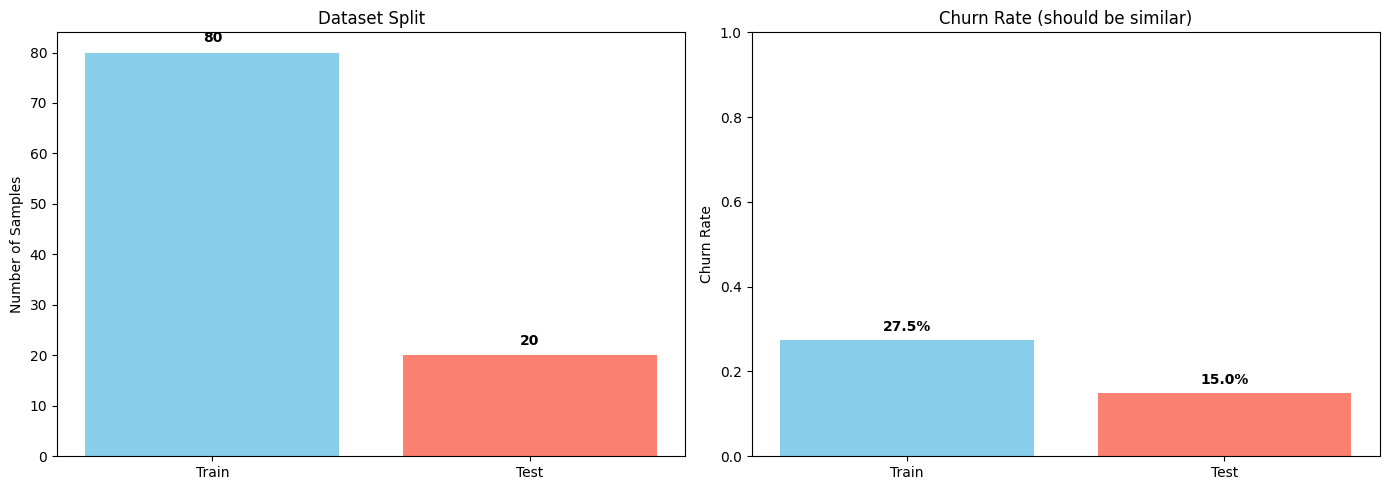

Train churn: 27.5%
Test churn:  15.0%

⚠️ If these differ a lot, use stratify parameter!


In [4]:
# Visualize split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Split sizes
split_sizes = pd.DataFrame({
    'Set': ['Train', 'Test'],
    'Count': [len(X_train), len(X_test)]
})
axes[0].bar(split_sizes['Set'], split_sizes['Count'], color=['skyblue', 'salmon'])
axes[0].set_title('Dataset Split')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(split_sizes['Count']):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Churn distribution
axes[1].bar(['Train', 'Test'], 
            [y_train.mean(), y_test.mean()],
            color=['skyblue', 'salmon'])
axes[1].set_title('Churn Rate (should be similar)')
axes[1].set_ylabel('Churn Rate')
axes[1].set_ylim([0, 1])
for i, v in enumerate([y_train.mean(), y_test.mean()]):
    axes[1].text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Train churn: {y_train.mean():.1%}")
print(f"Test churn:  {y_test.mean():.1%}")
print("\n⚠️ If these differ a lot, use stratify parameter!")

---
## 4. Stratified Split (For Imbalanced Data)

In [5]:
# Stratified: Preserves class proportions
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # ✅ Maintain class balance
    random_state=42
)

print("Regular Split:")
print(f"  Train churn: {y_train.mean():.1%}")
print(f"  Test churn:  {y_test.mean():.1%}")
print(f"  Difference:  {abs(y_train.mean() - y_test.mean()):.1%}")

print("\nStratified Split:")
print(f"  Train churn: {y_train_strat.mean():.1%}")
print(f"  Test churn:  {y_test_strat.mean():.1%}")
print(f"  Difference:  {abs(y_train_strat.mean() - y_test_strat.mean()):.1%}")

print("\n✅ USE STRATIFY when:")
print("  - Imbalanced classes (fraud: 1%, normal: 99%)")
print("  - Small datasets")
print("  - Classification problems")

Regular Split:
  Train churn: 27.5%
  Test churn:  15.0%
  Difference:  12.5%

Stratified Split:
  Train churn: 25.0%
  Test churn:  25.0%
  Difference:  0.0%

✅ USE STRATIFY when:
  - Imbalanced classes (fraud: 1%, normal: 99%)
  - Small datasets
  - Classification problems


---
## 5. Wrong: Testing on Training Data

In [6]:
# Train a model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# ❌ WRONG: Test on training data
train_accuracy = model.score(X_train, y_train)
print(f"❌ Train accuracy: {train_accuracy:.1%}")
print("   This is CHEATING! Model has seen this data.")

print("\n" + "="*50)

# ✅ CORRECT: Test on unseen data
test_accuracy = model.score(X_test, y_test)
print(f"✅ Test accuracy:  {test_accuracy:.1%}")
print("   This is REAL performance!")

print(f"\nOverfitting gap: {train_accuracy - test_accuracy:.1%}")
print("If gap > 10%, model is overfitting!")

❌ Train accuracy: 72.5%
   This is CHEATING! Model has seen this data.

✅ Test accuracy:  85.0%
   This is REAL performance!

Overfitting gap: -12.5%
If gap > 10%, model is overfitting!


---
## 6. Cross-Validation (Better Evaluation)

In [7]:
# K-Fold Cross-Validation: Split data into K parts
# Train on K-1, test on 1, repeat K times

cv_scores = cross_val_score(
    model, X, y,
    cv=5,              # 5-fold
    scoring='accuracy'
)

print("5-Fold Cross-Validation:")
print(f"  Fold 1: {cv_scores[0]:.1%}")
print(f"  Fold 2: {cv_scores[1]:.1%}")
print(f"  Fold 3: {cv_scores[2]:.1%}")
print(f"  Fold 4: {cv_scores[3]:.1%}")
print(f"  Fold 5: {cv_scores[4]:.1%}")

print(f"\nAverage: {cv_scores.mean():.1%} ± {cv_scores.std():.1%}")

print("\n✅ Cross-validation gives BETTER estimate")
print("✅ Uses all data for both training and testing")
print("✅ Reduces variance from single split")

5-Fold Cross-Validation:
  Fold 1: 75.0%
  Fold 2: 75.0%
  Fold 3: 75.0%
  Fold 4: 65.0%
  Fold 5: 75.0%

Average: 73.0% ± 4.0%

✅ Cross-validation gives BETTER estimate
✅ Uses all data for both training and testing
✅ Reduces variance from single split


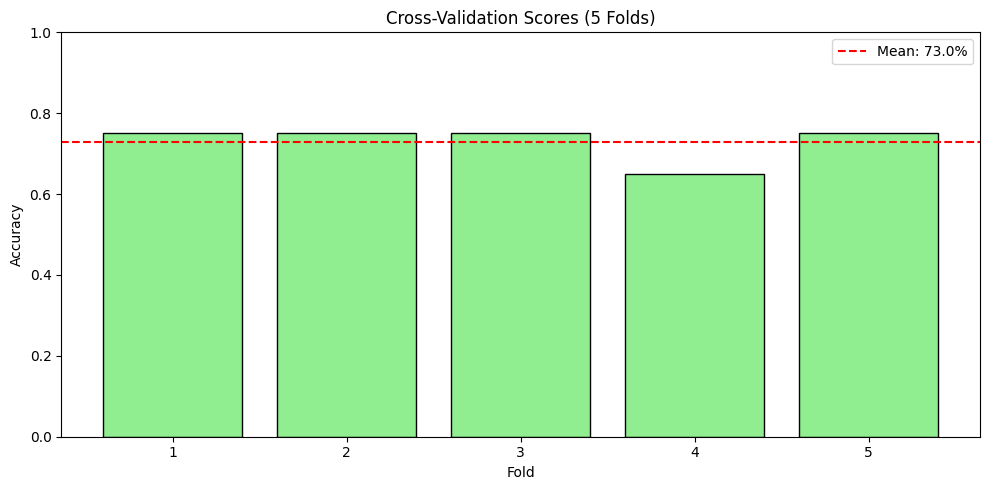

Each fold tests on different 20% of data


In [8]:
# Visualize cross-validation
plt.figure(figsize=(10, 5))
plt.bar(range(1, 6), cv_scores, color='lightgreen', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.1%}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Scores (5 Folds)')
plt.ylim([0, 1])
plt.legend()
plt.tight_layout()
plt.show()

print("Each fold tests on different 20% of data")

---
## 7. Stratified K-Fold (For Imbalanced)

In [9]:
# Stratified K-Fold: Maintains class balance in each fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_strat = cross_val_score(
    model, X, y,
    cv=skf,
    scoring='accuracy'
)

print("Regular K-Fold:")
print(f"  Mean: {cv_scores.mean():.1%} ± {cv_scores.std():.1%}")

print("\nStratified K-Fold:")
print(f"  Mean: {cv_scores_strat.mean():.1%} ± {cv_scores_strat.std():.1%}")

print("\n✅ USE Stratified K-Fold for:")
print("  - Imbalanced classification")
print("  - Small datasets")

Regular K-Fold:
  Mean: 73.0% ± 4.0%

Stratified K-Fold:
  Mean: 74.0% ± 2.0%

✅ USE Stratified K-Fold for:
  - Imbalanced classification
  - Small datasets


---
## 8. Common Mistakes

In [10]:
# Mistake 1: Forgetting to split
print("❌ Mistake 1: No train-test split")
model_wrong = LogisticRegression(random_state=42, max_iter=1000)
model_wrong.fit(X, y)
accuracy_wrong = model_wrong.score(X, y)
print(f"   'Accuracy': {accuracy_wrong:.1%}  ← Tested on training data!")

print("\n" + "="*50)

# Mistake 2: Splitting after preprocessing
print("❌ Mistake 2: Scale before split")
from sklearn.preprocessing import StandardScaler
X_scaled_wrong = StandardScaler().fit_transform(X)  # ❌ Scaled ALL data
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_scaled_wrong, y, test_size=0.2)
print("   Test data influenced scaler! (data leakage)")

print("\n" + "="*50)

# Mistake 3: Not using stratify for imbalanced data
print("❌ Mistake 3: Imbalanced split")
# Create imbalanced dataset
y_imbalanced = np.concatenate([np.ones(95), np.zeros(5)])  # 95% class 1
X_imbalanced = np.random.randn(100, 4)
X_tr, X_te, y_tr, y_te = train_test_split(X_imbalanced, y_imbalanced, test_size=0.2)
print(f"   Train: {y_tr.mean():.1%} | Test: {y_te.mean():.1%}  ← Different!")
print("   Should use stratify=y")

❌ Mistake 1: No train-test split
   'Accuracy': 75.0%  ← Tested on training data!

❌ Mistake 2: Scale before split
   Test data influenced scaler! (data leakage)

❌ Mistake 3: Imbalanced split
   Train: 93.8% | Test: 100.0%  ← Different!
   Should use stratify=y


---
## 9. Train-Validation-Test Split

In [11]:
# For hyperparameter tuning, need 3 sets:
# Train (60%), Validation (20%), Test (20%)

# Split 1: Train+Val vs Test
X_temp, X_test_final, y_temp, y_test_final = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Split 2: Train vs Validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42  # 0.25 of 80% = 20% total
)

print("3-Way Split:")
print(f"  Train:      {len(X_train_final):3d} samples ({len(X_train_final)/len(X):.0%})")
print(f"  Validation: {len(X_val):3d} samples ({len(X_val)/len(X):.0%})")
print(f"  Test:       {len(X_test_final):3d} samples ({len(X_test_final)/len(X):.0%})")

print("\nUsage:")
print("  Train:      Train model")
print("  Validation: Tune hyperparameters")
print("  Test:       Final evaluation (touch ONCE!)")

print("\n⚠️ NEVER use test set for tuning!")

3-Way Split:
  Train:       60 samples (60%)
  Validation:  20 samples (20%)
  Test:        20 samples (20%)

Usage:
  Train:      Train model
  Validation: Tune hyperparameters
  Test:       Final evaluation (touch ONCE!)

⚠️ NEVER use test set for tuning!


---
## Decision Tree: Which Split?

```
How much data do you have?
  < 100 samples
    → Use Cross-Validation (all data matters)
  
  100-10,000 samples
    Is data imbalanced?
      YES → Stratified K-Fold
      NO  → K-Fold (k=5 or k=10)
  
  > 10,000 samples
    Need hyperparameter tuning?
      YES → Train-Val-Test (60-20-20)
      NO  → Train-Test (80-20)
```

---
## Cheat Sheet

| Scenario | Recommended Split |
|----------|------------------|
| Small dataset (<1000) | 5-Fold CV |
| Imbalanced classes | Stratified K-Fold |
| Hyperparameter tuning | Train-Val-Test 60-20-20 |
| Large dataset (>10k) | Train-Test 80-20 |
| Time series | Don't shuffle! Use TimeSeriesSplit |
| Evaluate final model | Always use held-out test set |

---
## Key Takeaways

1. **Always split** before training
2. **80/20 split** is most common
3. **Use stratify** for imbalanced data
4. **Cross-validation** for better estimates
5. **Never touch test set** during tuning
6. **Split BEFORE preprocessing** (avoid leakage)
7. **Test accuracy** is what matters, not train

**Golden rule**: Test set = held-out data the model has NEVER seen!

---
## Your Turn

1. Load your dataset
2. Split into train/test (80/20)
3. Train a model and evaluate
4. Try 5-fold cross-validation
5. Compare results

In [12]:
# Your code here